# Notebook 01 — Audit du dataset (EDA, Rebuild 2026)

| | |
|---|---|
| **Projet** | Application Intelligente de Scoring Client |
| **Entreprise** | Orus Services — filiale Salafin, Bank of Africa |
| **Auteure** | Fatima Zahra Ait Lamine |
| **Année** | PFE 2025–2026 (rebuild du pipeline ML) |

---

## Objectif

Auditer les fichiers **officiels** Kaggle *Give Me Some Credit* avant toute modélisation :
structure et dictionnaire, cible, valeurs manquantes, doublons, valeurs impossibles,
sentinelles, distributions, relations features→défaut, risques de fuite, cohérence
train/test. Chaque constat se traduit par une décision de preprocessing (notebook 02).

Version notebook du rapport `docs/phase1_dataset_audit.md` — mêmes analyses, mêmes conclusions.

## 1. Chargement et dictionnaire des données

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'axes.titleweight': 'bold'})
import os
os.makedirs('figures', exist_ok=True)

TARGET = 'SeriousDlqin2yrs'
DELAY = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
         'NumberOfTime60-89DaysPastDueNotWorse']

tr = pd.read_csv('../data/GiveMeSomeCredit-training.csv', index_col=0)
te = pd.read_csv('../data/GiveMeSomeCredit-testing.csv', index_col=0)
print(f"training : {tr.shape[0]:,} × {tr.shape[1]} | testing : {te.shape[0]:,} × {te.shape[1]}")
print(f"colonnes identiques : {list(tr.columns) == list(te.columns)}")

# Dictionnaire officiel (nécessite xlrd — cf. requirements-notebooks.txt)
try:
    dico = pd.read_excel('../data/Data Dictionary.xls', header=1)
    print()
    print(dico.to_string(index=False, max_colwidth=80))
except ImportError as e:
    print(f"(Data Dictionary.xls non lu : {e} — voir docs/phase1_dataset_audit.md §1)")

training : 150,000 × 11 | testing : 101,503 × 11
colonnes identiques : True

                       Variable Name                                                                      Description       Type
                    SeriousDlqin2yrs                        Person experienced 90 days past due delinquency or worse         Y/N
RevolvingUtilizationOfUnsecuredLines Total balance on credit cards and personal lines of credit except real estate... percentage
                                 age                                                         Age of borrower in years    integer
NumberOfTime30-59DaysPastDueNotWorse Number of times borrower has been 30-59 days past due but no worse in the las...    integer
                           DebtRatio       Monthly debt payments, alimony,living costs divided by monthy gross income percentage
                       MonthlyIncome                                                                   Monthly income       real
     NumberOfOpenCre

Points clés du dictionnaire : `RevolvingUtilizationOfUnsecuredLines` et `DebtRatio` sont
définis comme des **percentages/ratios** — des valeurs en milliers y sont donc
*définitionnellement invalides*, pas de simples outliers. La cible = incident de paiement
grave (90 j+) sur la fenêtre de performance de 2 ans.

## 2. Vérification de la cible

training — {0: 139974, 1: 10026}
taux de défaut : 6.68%  (déséquilibre ≈ 13:1)
valeurs hors {0,1} : 0 | NaN : 0

testing — cible NaN : 101503 / 101503 (100%)
→ GiveMeSomeCredit-testing.csv est le fichier de SOUMISSION Kaggle (sans labels) :
  inutilisable pour l'évaluation supervisée. Le split train/test sera taillé dans
  le fichier training (149 390 lignes après nettoyage structurel).


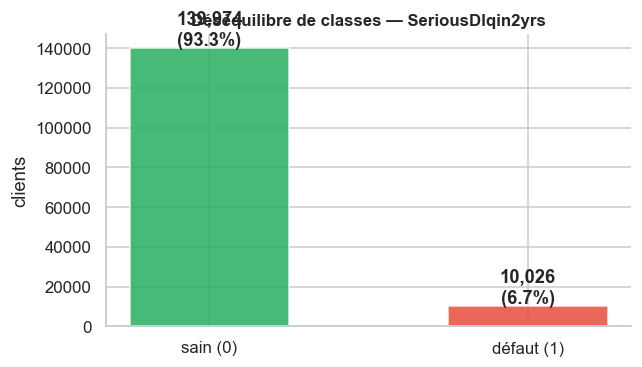

In [2]:
print('training —', dict(tr[TARGET].value_counts()))
print(f"taux de défaut : {tr[TARGET].mean()*100:.2f}%  (déséquilibre ≈ {int((tr[TARGET]==0).sum()/(tr[TARGET]==1).sum())}:1)")
print(f"valeurs hors {{0,1}} : {(~tr[TARGET].isin([0,1])).sum()} | NaN : {tr[TARGET].isna().sum()}")
print(f"\ntesting — cible NaN : {te[TARGET].isna().sum()} / {len(te)} (100%)")
print("→ GiveMeSomeCredit-testing.csv est le fichier de SOUMISSION Kaggle (sans labels) :")
print("  inutilisable pour l'évaluation supervisée. Le split train/test sera taillé dans")
print("  le fichier training (149 390 lignes après nettoyage structurel).")

fig, ax = plt.subplots(figsize=(6, 3.5))
counts = tr[TARGET].value_counts()
ax.bar(['sain (0)', 'défaut (1)'], counts.values, color=['#27ae60', '#e74c3c'],
       alpha=.85, edgecolor='white', width=.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 1500, f"{v:,}\n({v/len(tr)*100:.1f}%)", ha='center', fontweight='bold')
ax.set(title='Déséquilibre de classes — SeriousDlqin2yrs', ylabel='clients')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('figures/fig_R01_class_imbalance.png', dpi=120, bbox_inches='tight'); plt.show()

## 3. Valeurs manquantes — et leur caractère informatif (MAR)

In [3]:
for c in ['MonthlyIncome', 'NumberOfDependents']:
    n = tr[c].isna().sum()
    print(f"{c:<22} manquant : {n:,} ({n/len(tr)*100:.2f}%) | "
          f"défaut si présent {tr.loc[tr[c].notna(), TARGET].mean()*100:.2f}% "
          f"vs si manquant {tr.loc[tr[c].isna(), TARGET].mean()*100:.2f}%")
ab = pd.cut(tr.age, [0, 30, 40, 50, 60, 70, 120])
print('\n% de revenus manquants par tranche d\'âge :')
print((tr.MonthlyIncome.isna().groupby(ab, observed=True).mean()*100).round(1).to_string())
dep_na, inc_na = tr.NumberOfDependents.isna(), tr.MonthlyIncome.isna()
print(f"\nLignes sans dependents également sans revenu : {(dep_na & inc_na).sum()}/{dep_na.sum()} (100%)")
print('→ MAR : la missingness baisse le risque et croît avec l\'âge (retraités) —')
print('  elle porte de l\'information → indicateur income_missing (un seul flag suffit).')

MonthlyIncome          manquant : 29,731 (19.82%) | défaut si présent 6.95% vs si manquant 5.61%
NumberOfDependents     manquant : 3,924 (2.62%) | défaut si présent 6.74% vs si manquant 4.56%

% de revenus manquants par tranche d'âge :
age
(0, 30]      15.9
(30, 40]     13.6
(40, 50]     15.6
(50, 60]     19.8
(60, 70]     25.3
(70, 120]    30.6

Lignes sans dependents également sans revenu : 3924/3924 (100%)
→ MAR : la missingness baisse le risque et croît avec l'âge (retraités) —
  elle porte de l'information → indicateur income_missing (un seul flag suffit).


## 4. Doublons

In [4]:
feat = [c for c in tr.columns if c != TARGET]
dup_exact = tr.duplicated().sum()
dup_feat  = tr.duplicated(subset=feat).sum()
conf = tr.groupby(feat, dropna=False)[TARGET].nunique().gt(1).sum()
print(f"doublons exacts (11 colonnes)          : {dup_exact}")
print(f"vecteurs de features dupliqués          : {dup_feat}")
print(f"groupes à labels contradictoires        : {conf}")
print('→ Décision : retirer les doublons exacts AVANT le split (mémorisation train/test) ;')
print('  conserver les groupes contradictoires (personnes différentes, bruit réel).')

doublons exacts (11 colonnes)          : 609
vecteurs de features dupliqués          : 646
groupes à labels contradictoires        : 37
→ Décision : retirer les doublons exacts AVANT le split (mémorisation train/test) ;
  conserver les groupes contradictoires (personnes différentes, bruit réel).


## 5. Sentinelles 96 / 98 dans les colonnes de retards

In [5]:
sent = tr[DELAY].isin([96, 98]).any(axis=1)
both = tr[DELAY].isin([96, 98]).all(axis=1)
for c in DELAY:
    vc = tr[c].value_counts()
    print(f"{c:<42} 96 : {int(vc.get(96, 0)):>3} | 98 : {int(vc.get(98, 0)):>3} | max hors sentinelle : {int(tr.loc[tr[c] < 90, c].max())}")
print(f"\nlignes sentinelles : {sent.sum()} — toujours les 3 colonnes simultanément : {both.sum()}")
print(f"taux de défaut sentinelles : {tr.loc[sent, TARGET].mean()*100:.1f}% vs reste : {tr.loc[~sent, TARGET].mean()*100:.2f}%")
print('→ « Historique inconnu » ≠ « aucun retard » : NaN + flag delinq_info_missing.')
print('  (l\'ancien pipeline imputait à 0 retard et ignorait le code 96)')

NumberOfTime30-59DaysPastDueNotWorse       96 :   5 | 98 : 264 | max hors sentinelle : 13
NumberOfTimes90DaysLate                    96 :   5 | 98 : 264 | max hors sentinelle : 17
NumberOfTime60-89DaysPastDueNotWorse       96 :   5 | 98 : 264 | max hors sentinelle : 11

lignes sentinelles : 269 — toujours les 3 colonnes simultanément : 269
taux de défaut sentinelles : 54.6% vs reste : 6.60%
→ « Historique inconnu » ≠ « aucun retard » : NaN + flag delinq_info_missing.
  (l'ancien pipeline imputait à 0 retard et ignorait le code 96)


## 6. Valeurs impossibles — dont le piège DebtRatio

In [6]:
print(f"age == 0 : {(tr.age == 0).sum()} ligne | age > 100 : {(tr.age > 100).sum()} (max {tr.age.max()})")
ru = tr.RevolvingUtilizationOfUnsecuredLines
print(f"RevolvingUtil > 1 : {(ru > 1).sum()} ({(ru > 1).mean()*100:.2f}%) | > 2 : {(ru > 2).sum()} | max : {ru.max():,.0f}")
inc = tr.MonthlyIncome
print(f"MonthlyIncome == 0 : {(inc == 0).sum()} | == 1 : {(inc == 1).sum()} | max : {inc.max():,.0f} $/mois")
print(f"NumberOfDependents max : {tr.NumberOfDependents.max():.0f} (training) / {te.NumberOfDependents.max():.0f} (testing !)")

miss = inc.isna() | (inc <= 1)
print(f"\n— Le piège DebtRatio (dictionnaire : ratio) —")
print(f"DebtRatio médian | revenu valide : {tr.loc[~miss, 'DebtRatio'].median():.3f} | revenu absent/placeholder : {tr.loc[miss, 'DebtRatio'].median():,.0f}")
print(f"DebtRatio > 2 : {(tr.DebtRatio > 2).sum():,} lignes ({(tr.DebtRatio > 2).mean()*100:.1f}%) — dont revenu absent/0/1 : "
      f"{((tr.DebtRatio > 2) & miss).mean() / max((tr.DebtRatio > 2).mean(), 1e-9)*100:.0f}%")
print('→ Quand le revenu est absent, la colonne contient des CHARGES ABSOLUES en dollars,')
print('  pas un ratio : deux grandeurs physiques dans une même colonne.')

age == 0 : 1 ligne | age > 100 : 13 (max 109)
RevolvingUtil > 1 : 3321 (2.21%) | > 2 : 371 | max : 50,708
MonthlyIncome == 0 : 1634 | == 1 : 605 | max : 3,008,750 $/mois
NumberOfDependents max : 20 (training) / 43 (testing !)

— Le piège DebtRatio (dictionnaire : ratio) —
DebtRatio médian | revenu valide : 0.291 | revenu absent/placeholder : 1,130
DebtRatio > 2 : 31,045 lignes (20.7%) — dont revenu absent/0/1 : 96%
→ Quand le revenu est absent, la colonne contient des CHARGES ABSOLUES en dollars,
  pas un ratio : deux grandeurs physiques dans une même colonne.


## 7. Distributions

In [7]:
q = tr.describe(percentiles=[.01, .25, .5, .75, .95, .99, .999]).T
print(q[['min', '1%', '50%', '95%', '99%', '99.9%', 'max']].round(3).to_string())
print('\nasymétrie (skewness) :')
print(tr.skew(numeric_only=True).sort_values(ascending=False).round(1).to_string())

                                      min    1%       50%      95%        99%      99.9%        max
SeriousDlqin2yrs                      0.0   0.0     0.000      1.0      1.000      1.000        1.0
RevolvingUtilizationOfUnsecuredLines  0.0   0.0     0.154      1.0      1.093   1571.006    50708.0
age                                   0.0  24.0    52.000     78.0     87.000     94.000      109.0
NumberOfTime30-59DaysPastDueNotWorse  0.0   0.0     0.000      2.0      4.000     98.000       98.0
DebtRatio                             0.0   0.0     0.367   2449.0   4979.040  10613.074   329664.0
MonthlyIncome                         0.0   0.0  5400.000  14587.6  25000.000  78395.748  3008750.0
NumberOfOpenCreditLinesAndLoans       0.0   0.0     8.000     18.0     24.000     34.000       58.0
NumberOfTimes90DaysLate               0.0   0.0     0.000      1.0      3.000     98.000       98.0
NumberRealEstateLoansOrLines          0.0   0.0     1.000      3.0      4.000      9.000       54.0




asymétrie (skewness) :
MonthlyIncome                           114.0
RevolvingUtilizationOfUnsecuredLines     97.6
DebtRatio                                95.2
NumberOfTime60-89DaysPastDueNotWorse     23.3
NumberOfTimes90DaysLate                  23.1
NumberOfTime30-59DaysPastDueNotWorse     22.6
NumberRealEstateLoansOrLines              3.5
SeriousDlqin2yrs                          3.5
NumberOfDependents                        1.6
NumberOfOpenCreditLinesAndLoans           1.2
age                                       0.2


## 8. Relations features → défaut

La corrélation de Pearson est trompeuse ici (celle de `RevolvingUtilization` vaut −0.002 à
cause du max 50 708 alors que c'est le prédicteur le plus fort) — on regarde le **taux de
défaut par bande**.

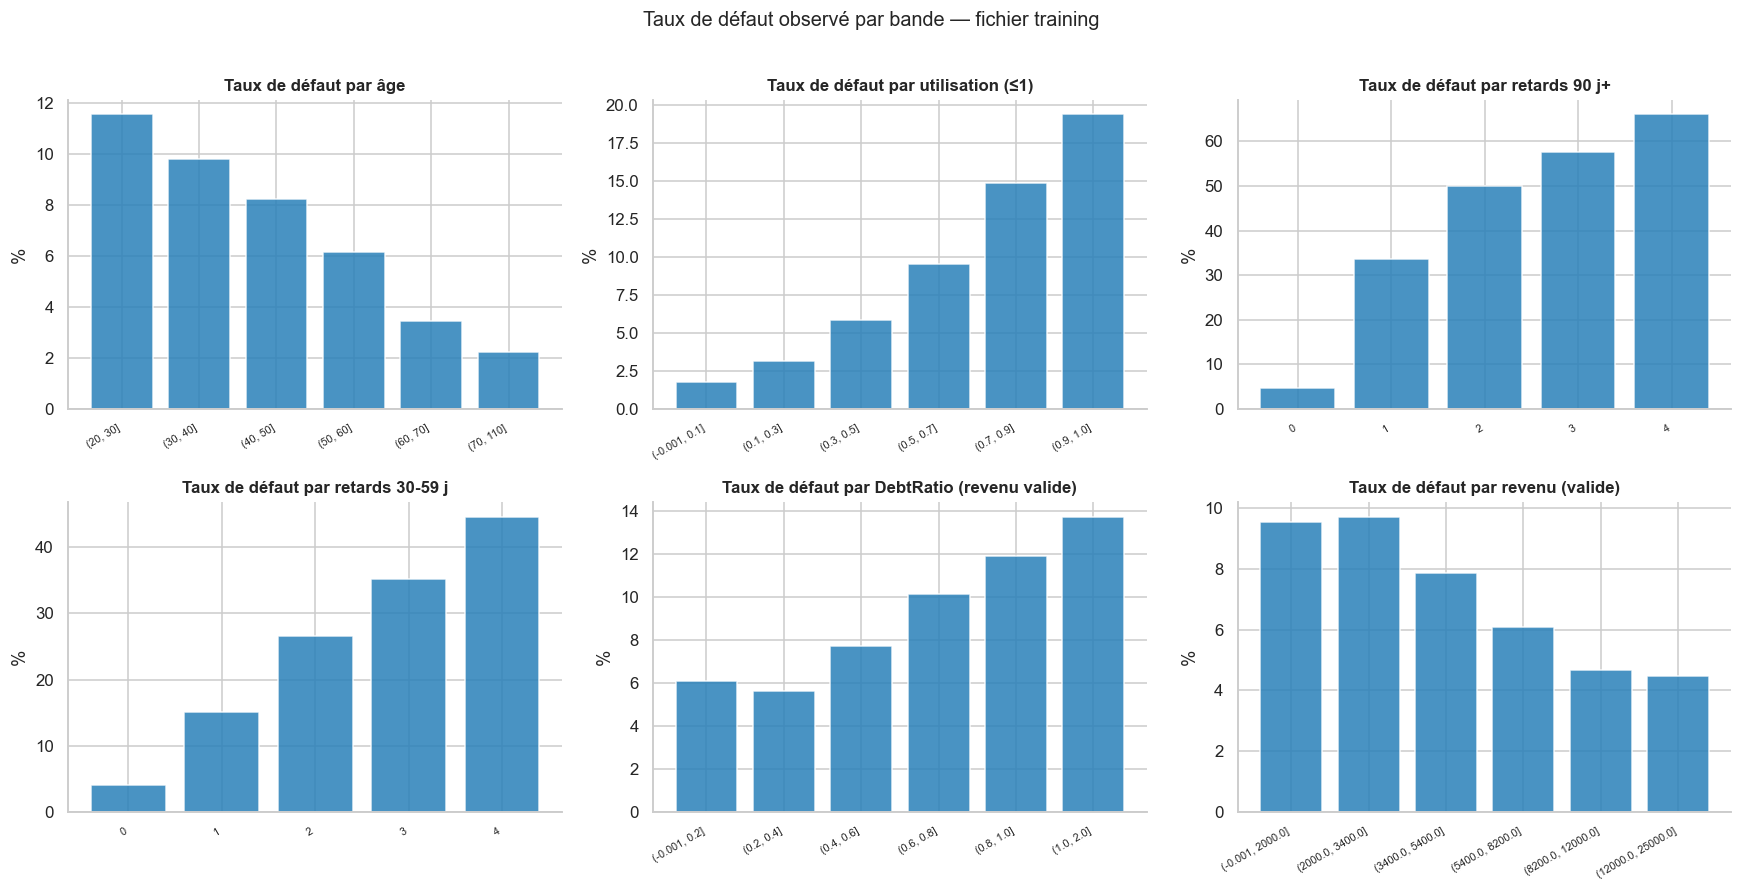

age : 11.6% (≤30) → 2.3% (70+) — décroissance monotone RÉELLE du risque avec l'âge
utilisation : 1.8% → 19.4% | retards 90j : 4.6% (0) → 33.7% (1) → 49.9% (2)


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
panels = []
panels.append((pd.cut(tr.age, [20, 30, 40, 50, 60, 70, 110]), 'âge', 0))
panels.append((pd.cut(tr.loc[ru <= 1, 'RevolvingUtilizationOfUnsecuredLines'], [0, .1, .3, .5, .7, .9, 1], include_lowest=True), 'utilisation (≤1)', 1))
panels.append((tr.loc[tr['NumberOfTimes90DaysLate'] < 90, 'NumberOfTimes90DaysLate'].clip(upper=4), 'retards 90 j+', 2))
panels.append((tr.loc[tr['NumberOfTime30-59DaysPastDueNotWorse'] < 90, 'NumberOfTime30-59DaysPastDueNotWorse'].clip(upper=4), 'retards 30-59 j', 3))
valid = tr.MonthlyIncome.notna() & (tr.MonthlyIncome > 1)
panels.append((pd.cut(tr.loc[valid, 'DebtRatio'], [0, .2, .4, .6, .8, 1, 2], include_lowest=True), 'DebtRatio (revenu valide)', 4))
panels.append((pd.cut(tr.loc[valid, 'MonthlyIncome'], [0, 2000, 3400, 5400, 8200, 12000, 25000], include_lowest=True), 'revenu (valide)', 5))

for b, titre, i in panels:
    ax = axes.flat[i]
    r = tr.loc[b.index].groupby(b, observed=True)[TARGET].mean() * 100
    ax.bar(range(len(r)), r.values, color='#2980b9', alpha=.85, edgecolor='white')
    ax.set_xticks(range(len(r)))
    ax.set_xticklabels([str(x) for x in r.index], rotation=30, fontsize=7, ha='right')
    ax.set(title=f'Taux de défaut par {titre}', ylabel='%')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Taux de défaut observé par bande — fichier training', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig_R01_default_rates_by_band.png', dpi=120, bbox_inches='tight')
plt.show()
print('age : 11.6% (≤30) → 2.3% (70+) — décroissance monotone RÉELLE du risque avec l\'âge')
print('utilisation : 1.8% → 19.4% | retards 90j : 4.6% (0) → 33.7% (1) → 49.9% (2)')

## 9. Risques de fuite et cohérence train/test

- Aucune feature n'est dérivée de la cible ; les compteurs de retards sont *historiques*, la
  cible est *future* (fenêtre 2 ans) → prédicteurs comportementaux légitimes.
- La seule vraie fuite serait *procédurale* : statistiques calées avant split, doublons après
  split, ou **cible reconstruite depuis les features** (erreur de l'ancien pipeline, éliminée).

In [9]:
print(f"{'feature':<40} {'méd. train':>11} {'méd. test':>10} {'p99 train':>10} {'p99 test':>9}")
feat = [c for c in tr.columns if c != TARGET]
for c in feat:
    a, b = tr[c].dropna(), te[c].dropna()
    print(f"{c:<40} {a.median():>11.3g} {b.median():>10.3g} {a.quantile(.99):>10.3g} {b.quantile(.99):>9.3g}")
print(f"\nrevenus manquants : {tr.MonthlyIncome.isna().mean()*100:.2f}% vs {te.MonthlyIncome.isna().mean()*100:.2f}%")
print('→ Distributions quasi identiques : le fichier labellisé est représentatif.')

feature                                   méd. train  méd. test  p99 train  p99 test
RevolvingUtilizationOfUnsecuredLines           0.154      0.153       1.09      1.09
age                                               52         52         87        87
NumberOfTime30-59DaysPastDueNotWorse               0          0          4         4
DebtRatio                                      0.367      0.364   4.98e+03  4.96e+03
MonthlyIncome                                5.4e+03    5.4e+03    2.5e+04  2.59e+04
NumberOfOpenCreditLinesAndLoans                    8          8         24        25
NumberOfTimes90DaysLate                            0          0          3         3
NumberRealEstateLoansOrLines                       1          1          4         4
NumberOfTime60-89DaysPastDueNotWorse               0          0          2         2
NumberOfDependents                                 0          0          4         4

revenus manquants : 19.82% vs 19.81%
→ Distributions quasi ident

## 10. Synthèse — problèmes identifiés et décisions (implémentées au notebook 02)

| # | Problème | Décision |
|---|---|---|
| P1 | Fichier testing sans labels | Split 80/20 stratifié dans le fichier training ; CV 5-fold dans le train |
| P2 | DebtRatio = montants absolus si revenu absent/0/1 (~21 %) | DebtRatio → NaN si revenu invalide ; plafond p99 sinon |
| P3 | Sentinelles 96 **et** 98 (269 lignes, défaut 54.6 %) | → NaN + flag `delinq_info_missing` |
| P4 | 609 doublons exacts, 37 groupes contradictoires | Doublons exacts retirés avant split ; contradictoires conservés |
| P5 | Déséquilibre 14:1 | Pondération de classes + calibration ; **pas de SMOTE** |
| P6 | RevolvingUtil > 2 invalide (371 lignes) | → NaN (le défaut s'effondre au-delà de 2 : valeurs corrompues) |
| P7 | Missingness informative (MAR) | Flag `income_missing` ; imputation médiane pour LR/RF uniquement |
| P8 | Queues extrêmes (revenu 3 M$, dependents 43 au test) | Winsorisation p99.5 / p99.9 fittée sur train |
| P9 | `age == 0` (1 ligne) | Suppression |

**Prochaine étape → Notebook 02 — Preprocessing** (seuils justifiés statistiquement,
vérification empirique des monotonies, artefacts sérialisés).